In [1]:
library(tidyverse)
library(dbplyr)
library(bigrquery)
library(lubridate)

bq_auth()

project_id = "yhcr-prd-bradfor-bia-core"

# create connection to database
con <- DBI::dbConnect(bigrquery::bigquery(), 
                      project = project_id)

print(paste0("Connected to : ", project_id))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘dbplyr’


The following objects are masked from ‘package:dplyr’:

    ident, sql




[1] "Connected to : yhcr-prd-bradfor-bia-core"


# Person

In [2]:
person_data = "CB_2489.person_targetage"

person_table <- tbl(con, person_data) |> 
    select(person_id, birth_date, gender_source_value, ethnicity_source_value)


In [3]:
head(person_table)

# Source:   SQL [6 x 4]
# Database: BigQueryConnection
  person_id                birth_date gender_source_value ethnicity_source_value
  <chr>                    <date>     <chr>               <chr>                 
1 D27CE553B8DA52E66BCBA43… 2000-09-15 F                   Unknown/Refuse to say 
2 9F33F6D292805042AF92186… 2000-09-15 F                   Unknown/Refuse to say 
3 C38AD0B73560547A95C529E… 2000-09-15 F                   Unknown/Refuse to say 
4 03A81FF3A58E65546A42780… 2000-09-15 F                   Unknown/Refuse to say 
5 8C9979BE485657CDE5AC923… 2000-09-15 F                   Unknown/Refuse to say 
6 00ED2E8CBC0AE48B370DBB7… 2000-09-15 F                   Unknown/Refuse to say 

#### Clean Gender

In [4]:
person_table |> 
  distinct(gender_source_value) |> 
  pull(gender_source_value)

[1] "F"      "Female" "M"      "2"      "1"      NA       "U"      "Male"

In [5]:
person_table <- person_table |> 
  mutate(
    gender_source_value = case_when(
      gender_source_value %in% c("F", "Female", "1") ~ "F",
      gender_source_value %in% c("M", "Male", "2") ~ "M",
      gender_source_value %in% c("N", "I", "U", "", NA) ~ NA_character_,
      TRUE ~ NA_character_  # Handle any other unexpected cases
    )
  )

In [6]:
person_table |> 
  distinct(gender_source_value) |> 
  pull(gender_source_value)

[1] "F" "M" NA

In [7]:
person_table |> 
  filter(is.na(gender_source_value)) |> 
  count()

# Source:   SQL [1 x 1]
# Database: BigQueryConnection
      n
  <int>
1     4

#### Clean Ethnicity

In [8]:
person_table |> 
  distinct(ethnicity_source_value) |> 
  pull(ethnicity_source_value)

[1] "Unknown/Refuse to say"                                                                                                                         
 [2] "White:Any other White background"                                                                                                              
 [3] "Asian or Asian British: Bangladeshi - England and Wales ethnic category 2011 census"                                                           
 [4] "Asian or Asian British: Chinese - England and Wales ethnic category 2011 census"                                                               
 [5] "Asian or Asian British: Indian - England and Wales ethnic category 2011 census"                                                                
 [6] "Asian or Asian British: Pakistani - England and Wales ethnic category 2011 census"                                                             
 [7] "Asian or Asian British: any other Asian background - England and Wales ethnic category 2011 census"                                            
 [8] "Black or African or Caribbean or Black British: African - England and Wales ethnic category 2011 census"                                       
 [9] "Black or African or Caribbean or Black British: Caribbean - England and Wales ethnic category 2011 census"                                     
[10] "Black or African or Caribbean or Black British: other Black or African or Caribbean background - England and Wales ethnic category 2011 census"
[11] "Mixed multiple ethnic groups: White and Asian - England and Wales ethnic category 2011 census"                                                 
[12] "Mixed multiple ethnic groups: White and Black African - England and Wales ethnic category 2011 census"                                         
[13] "Mixed multiple ethnic groups: White and Black Caribbean - England and Wales ethnic category 2011 census"                                       
[14] "Mixed multiple ethnic groups: any other Mixed or multiple ethnic background - England and Wales ethnic category 2011 census"                   
[15] "Other ethnic group: any other ethnic group - England and Wales ethnic category 2011 census"                                                    
[16] "White: English or Welsh or Scottish or Northern Irish or British - England and Wales ethnic category 2011 census"                              
[17] "White: Irish - England and Wales ethnic category 2011 census"                                                                                  
[18] "Other ethnic group: Arab - England and Wales ethnic category 2011 census"                                                                      
[19] "White: Gypsy or Irish Traveller - England and Wales ethnic category 2011 census"

In [9]:
person_table <- person_table |> 
  mutate(
    ethnicity_source_value = sql("REGEXP_REPLACE(ethnicity_source_value, r' - England and Wales ethnic category 2011 census', '')")
  )


In [10]:
person_table |> 
  distinct(ethnicity_source_value) |> 
  pull(ethnicity_source_value)

[1] "Unknown/Refuse to say"                                                                         
 [2] "White:Any other White background"                                                              
 [3] "Asian or Asian British: Bangladeshi"                                                           
 [4] "Asian or Asian British: Chinese"                                                               
 [5] "Asian or Asian British: Indian"                                                                
 [6] "Asian or Asian British: Pakistani"                                                             
 [7] "Asian or Asian British: any other Asian background"                                            
 [8] "Black or African or Caribbean or Black British: African"                                       
 [9] "Black or African or Caribbean or Black British: Caribbean"                                     
[10] "Black or African or Caribbean or Black British: other Black or African or Caribbean background"
[11] "Mixed multiple ethnic groups: White and Asian"                                                 
[12] "Mixed multiple ethnic groups: White and Black African"                                         
[13] "Mixed multiple ethnic groups: White and Black Caribbean"                                       
[14] "Mixed multiple ethnic groups: any other Mixed or multiple ethnic background"                   
[15] "Other ethnic group: any other ethnic group"                                                    
[16] "White: English or Welsh or Scottish or Northern Irish or British"                              
[17] "White: Irish"                                                                                  
[18] "Other ethnic group: Arab"                                                                      
[19] "White: Gypsy or Irish Traveller"

In [11]:
person_table <- person_table |>     
    mutate(ethnicity = case_when(
        str_detect(ethnicity_source_value, "Unknown") ~ NA_character_,
        str_detect(ethnicity_source_value, "Asian or Asian British: Indian") ~ "South Asian",
        str_detect(ethnicity_source_value, "Asian or Asian British: Pakistani") ~ "South Asian",
        str_detect(ethnicity_source_value, "Asian or Asian British: Bangladeshi") ~ "South Asian",
        str_detect(ethnicity_source_value, "White: English or Welsh or Scottish or Northern Irish or British") ~ "White British",
        str_detect(ethnicity_source_value, "White: Gypsy or Irish Traveller") ~ "Gypsy or Irish Traveller",
        TRUE ~ "Other"
    ))

In [12]:
person_table |> 
  distinct(ethnicity) |> 
  pull(ethnicity)

[1] NA                         "Other"                   
[3] "South Asian"              "White British"           
[5] "Gypsy or Irish Traveller"

In [13]:
person_table |> 
  filter(is.na(ethnicity)) |> 
  count()

# Source:   SQL [1 x 1]
# Database: BigQueryConnection
      n
  <int>
1  5539

In [14]:
person_table <- person_table |>
    rename(gender = gender_source_value) |>
    select(-ethnicity_source_value)

person_table

# Source:   SQL [?? x 4]
# Database: BigQueryConnection
   person_id                                         birth_date gender ethnicity
   <chr>                                             <date>     <chr>  <chr>    
 1 D27CE553B8DA52E66BCBA43420F6F53DAEBF9FE286436184… 2000-09-15 F      NA       
 2 9F33F6D292805042AF92186788B71C7302C7E976F6C148C3… 2000-09-15 F      NA       
 3 C38AD0B73560547A95C529E42A9CF6E1E06282163BB419DC… 2000-09-15 F      NA       
 4 03A81FF3A58E65546A42780919E74680BF016F6D3E8FE1FA… 2000-09-15 F      NA       
 5 8C9979BE485657CDE5AC92361D6E454DC61C1396BCC38F77… 2000-09-15 F      NA       
 6 00ED2E8CBC0AE48B370DBB70FB9440A00BD65113392DE33A… 2000-09-15 F      NA       
 7 F9AA50A652E66CCDB96FE50B68A1035B2612296C86D2B839… 2000-09-15 F      NA       
 8 CD0324C008286EAC2FC26512D536BD3B77A0809E3D769815… 2000-10-15 F      NA       
 9 DC56B789C3A6AFDA2293B2E9B0C7A8F219D04FAF66BF216E… 2000-10-15 F      NA       
10 7E3563E819DF69145580E7FF81D89DEBA0A57A12F77842F6… 

In [15]:
person_table |>
    summarise(num_unique = n_distinct(person_id))

# Source:   SQL [1 x 1]
# Database: BigQueryConnection
  num_unique
       <int>
1      22101

In [16]:
person_table |>
    tally()

# Source:   SQL [1 x 1]
# Database: BigQueryConnection
      n
  <int>
1 22992

In [17]:
distinct_person_table <- person_table |>
    distinct()

In [18]:
distinct_person_table |>
    tally()

# Source:   SQL [1 x 1]
# Database: BigQueryConnection
      n
  <int>
1 22101

#### Get more ethnicity data

In [19]:
school_census_data = "CB_2489.cb_StudentAdditionalInfoFromCensus"

In [20]:
school_census_table <- tbl(con, school_census_data) |>
    select(person_id, Ethnicity)

In [21]:
head(school_census_table)

# Source:   SQL [6 x 2]
# Database: BigQueryConnection
  person_id                                                        Ethnicity
  <chr>                                                            <chr>    
1 4A2AD68DFB6F3E01578C742C05A033F477237CC24FE0C7F1B64DA5E58EB83BD9 MOTH     
2 0A9D44CD352FE47273953BD7AB1FA9E4335B565FDFA69B045D9506F3829463C0 BOTB     
3 41D31CEA128C214AD816B1FE3D46C7A78A5DEC9CEF55453C96CF07AE16F3A5F4 WEEU     
4 21FD3187568CC045195329EADD277AE441E63BD8BC97F115AAF7E985DF983068 OKRD     
5 83F6D7C1D1A9FEEFCA1F5C2DD380FAD3BFA21B2FCE7FA7639494ECE79D2CB0A7 WEEU     
6 9F5D0A6E879AB05C11177B3AA26EBB3FE11E7F7FA0A8A2BA094E813E2874BD46 CHNE     

In [22]:
school_census_table |> 
  filter(is.na(Ethnicity)) |> 
  count()

# Source:   SQL [1 x 1]
# Database: BigQueryConnection
        n
    <int>
1 3105654

In [23]:
school_census_table <- school_census_table |>
    filter(!is.na(Ethnicity))

In [24]:
school_census_table |> 
  distinct(Ethnicity) |> 
  pull(Ethnicity)

[1] "WALB" "OARA" "MWAO" "AKPA" "WOWB" "MWOE" "MCOE" "BSUD" "BOTB" "COCH"
 [11] "BCON" "WPOR" "ASLT" "WGRK" "WGRC" "OMAL" "OTHA" "AIND" "AMPK" "APKN"
 [21] "BNAM" "WEEU" "WSCO" "MWAP" "MWBA" "BAOF" "WTUK" "OFIL" "WWEU" "WCOR"
 [31] "ASRO" "WROR" "AKAO" "OIRN" "WTUR" "CHKC" "WSER" "WCRO" "MWBC" "WOTH"
 [41] "WTUC" "CMAL" "WGRE" "WROM" "OAFG" "BSOM" "BAFR" "MBOE" "REFU" "CHNE"
 [51] "WROG" "OLIB" "MWAI" "WIRI" "MWCH" "WIRT" "MABL" "ANEP" "ASNL" "OLAM"
 [61] "WKOS" "OKOR" "OLEB" "OJPN" "OOEG" "NOBT" "BCRB" "BOTH" "MOTH" "BNGN"
 [71] "BGHA" "MAOE" "MOTM" "WITA" "AAFR" "OIRQ" "OMRC" "BANN" "OPOL" "MACH"
 [81] "OEGY" "OVIE" "WBOS" "AOTH" "MWAS" "OOTH" "WOTW" "WEUR" "AOTA" "OKRD"
 [91] "OYEM" "WROO" "BEUR" "WWEL" "BSLN" "ABAN" "AOPK" "WBRI" "WENG" "11  "

In [25]:
school_census_table <- school_census_table |> 
  mutate(
    Ethnicity = case_when(
      Ethnicity %in% c("ABAN", "AIND", "AKAO", "AKPA", "AMPK", "AOPK", "APKN") ~ "South Asian",
      Ethnicity %in% c("WBRI", "WENG", "WCOR", "WSCO", "WOWB", "WWEL", "WIRI") ~ "White British",
        Ethnicity %in% c("WROG", "WROM", "WROO") ~ "Gypsy or Irish Traveller",
      Ethnicity %in% c("NOBT", "UNCL", "REFU", "", NA) ~ NA_character_,
      TRUE ~ "Other"  # Handle any other unexpected cases
    )
  ) 

In [26]:
school_census_table |> 
  distinct(Ethnicity) |> 
  pull(Ethnicity)

[1] "White British"            "Other"                   
[3] "Gypsy or Irish Traveller" "South Asian"             
[5] NA

In [27]:
head(school_census_table)

# Source:   SQL [6 x 2]
# Database: BigQueryConnection
  person_id                                                        Ethnicity
  <chr>                                                            <chr>    
1 2C2ACF8DF049F9099B4B64781B3925AF10302FBA0BABB5A69B4C05EAA06EDF91 Other    
2 91E0083AFC7FF47A39987EE5806369C563E4DC1D46769E4F9EE3D45F8FBC4F4B Other    
3 777105A1F6692B9760AF1DCBE42999B1C0AFF26FDFE1E0829A6748FFA77249F9 Other    
4 19DFE3DF5202390B2C95FCD78C2E3818A3F3C22442CFBF89B8DF85E4EA156480 Other    
5 2CDAEE9B60AE5D979AF574E621397B8272154F1EE8D37917653539E4A44F86FB Other    
6 ADDD983979FB7E8833C5CBE964B604ADDED050A2033E65AE384D1941F98E7F3A Other    

In [28]:
school_census_table |>
    summarise(num_unique = n_distinct(person_id))

# Source:   SQL [1 x 1]
# Database: BigQueryConnection
  num_unique
       <int>
1     300615

In [29]:
school_census_table |>
    tally()

# Source:   SQL [1 x 1]
# Database: BigQueryConnection
        n
    <int>
1 3709036

In [30]:
school_census_table_filtered <- school_census_table %>%
  semi_join(distinct_person_table, by = "person_id")

In [31]:
school_census_table_filtered |>
    summarise(num_unique = n_distinct(person_id))

# Source:   SQL [1 x 1]
# Database: BigQueryConnection
  num_unique
       <int>
1      18984

In [32]:
school_census_table_filtered |>
    tally()

# Source:   SQL [1 x 1]
# Database: BigQueryConnection
       n
   <int>
1 363694

In [33]:
school_census_table_filtered <- school_census_table_filtered |> 
  distinct(person_id, .keep_all = TRUE)

In [34]:
combined_ethnicity <- distinct_person_table |> 
    rename(person_ethnicity = ethnicity) |> 
    left_join(school_census_table_filtered, by = join_by(person_id)) |> 
    mutate(CombinedEthnicity = coalesce(person_ethnicity, Ethnicity))

In [35]:
head(combined_ethnicity)

# Source:   SQL [6 x 6]
# Database: BigQueryConnection
  person_id       birth_date gender person_ethnicity Ethnicity CombinedEthnicity
  <chr>           <date>     <chr>  <chr>            <chr>     <chr>            
1 D27CE553B8DA52… 2000-09-15 F      NA               South As… South Asian      
2 9F33F6D2928050… 2000-09-15 F      NA               South As… South Asian      
3 C38AD0B7356054… 2000-09-15 F      NA               South As… South Asian      
4 03A81FF3A58E65… 2000-09-15 F      NA               NA        NA               
5 8C9979BE485657… 2000-09-15 F      NA               White Br… White British    
6 00ED2E8CBC0AE4… 2000-09-15 F      NA               White Br… White British    

In [36]:
combined_ethnicity |>
    summarise(num_unique = n_distinct(person_id))

# Source:   SQL [1 x 1]
# Database: BigQueryConnection
  num_unique
       <int>
1      22101

In [37]:
combined_ethnicity |>
    tally()

# Source:   SQL [1 x 1]
# Database: BigQueryConnection
      n
  <int>
1 22101

In [38]:
data <- combined_ethnicity |> 
    select(person_id, birth_date, gender, CombinedEthnicity)

data

# Source:   SQL [?? x 4]
# Database: BigQueryConnection
   person_id                                 birth_date gender CombinedEthnicity
   <chr>                                     <date>     <chr>  <chr>            
 1 D27CE553B8DA52E66BCBA43420F6F53DAEBF9FE2… 2000-09-15 F      South Asian      
 2 9F33F6D292805042AF92186788B71C7302C7E976… 2000-09-15 F      South Asian      
 3 C38AD0B73560547A95C529E42A9CF6E1E0628216… 2000-09-15 F      South Asian      
 4 03A81FF3A58E65546A42780919E74680BF016F6D… 2000-09-15 F      NA               
 5 8C9979BE485657CDE5AC92361D6E454DC61C1396… 2000-09-15 F      White British    
 6 00ED2E8CBC0AE48B370DBB70FB9440A00BD65113… 2000-09-15 F      White British    
 7 F9AA50A652E66CCDB96FE50B68A1035B2612296C… 2000-09-15 F      White British    
 8 CD0324C008286EAC2FC26512D536BD3B77A0809E… 2000-10-15 F      NA               
 9 DC56B789C3A6AFDA2293B2E9B0C7A8F219D04FAF… 2000-10-15 F      South Asian      
10 7E3563E819DF69145580E7FF81D89DEBA0A57A12… 2000-10-

In [39]:
data |>
    summarise(num_unique = n_distinct(person_id))

# Source:   SQL [1 x 1]
# Database: BigQueryConnection
  num_unique
       <int>
1      22101

In [40]:
data |>
    tally()

# Source:   SQL [1 x 1]
# Database: BigQueryConnection
      n
  <int>
1 22101

In [41]:
data_df <- data |>
    collect()

In [42]:
data_df

person_id,birth_date,gender,CombinedEthnicity
<chr>,<date>,<chr>,<chr>
D27CE553B8DA52E66BCBA43420F6F53DAEBF9FE2864361849339028B6B002695,2000-09-15,F,South Asian
9F33F6D292805042AF92186788B71C7302C7E976F6C148C34FDE62B157C03928,2000-09-15,F,South Asian
C38AD0B73560547A95C529E42A9CF6E1E06282163BB419DC2C1451422CD20CE0,2000-09-15,F,South Asian
03A81FF3A58E65546A42780919E74680BF016F6D3E8FE1FA64FFD9B9E436B795,2000-09-15,F,NA
8C9979BE485657CDE5AC92361D6E454DC61C1396BCC38F77933217649F802EFF,2000-09-15,F,White British
00ED2E8CBC0AE48B370DBB70FB9440A00BD65113392DE33A5E14380D5C306075,2000-09-15,F,White British
F9AA50A652E66CCDB96FE50B68A1035B2612296C86D2B839A97D5B3533FEA597,2000-09-15,F,White British
CD0324C008286EAC2FC26512D536BD3B77A0809E3D769815154FF427D96317AF,2000-10-15,F,NA
DC56B789C3A6AFDA2293B2E9B0C7A8F219D04FAF66BF216E174CF76C8D138FFA,2000-10-15,F,South Asian


In [43]:
data_df |>
    summarise(num_unique = n_distinct(person_id))

num_unique
<int>
22101


In [44]:
data_df <- data_df |>
    mutate(cohort = ifelse(as.Date(birth_date) < as.Date("2001-09-01"), '2000/01', '2001/02'))
            
        

In [45]:
data_df

person_id,birth_date,gender,CombinedEthnicity,cohort
<chr>,<date>,<chr>,<chr>,<chr>
D27CE553B8DA52E66BCBA43420F6F53DAEBF9FE2864361849339028B6B002695,2000-09-15,F,South Asian,2000/01
9F33F6D292805042AF92186788B71C7302C7E976F6C148C34FDE62B157C03928,2000-09-15,F,South Asian,2000/01
C38AD0B73560547A95C529E42A9CF6E1E06282163BB419DC2C1451422CD20CE0,2000-09-15,F,South Asian,2000/01
03A81FF3A58E65546A42780919E74680BF016F6D3E8FE1FA64FFD9B9E436B795,2000-09-15,F,NA,2000/01
8C9979BE485657CDE5AC92361D6E454DC61C1396BCC38F77933217649F802EFF,2000-09-15,F,White British,2000/01
00ED2E8CBC0AE48B370DBB70FB9440A00BD65113392DE33A5E14380D5C306075,2000-09-15,F,White British,2000/01
F9AA50A652E66CCDB96FE50B68A1035B2612296C86D2B839A97D5B3533FEA597,2000-09-15,F,White British,2000/01
CD0324C008286EAC2FC26512D536BD3B77A0809E3D769815154FF427D96317AF,2000-10-15,F,NA,2000/01
DC56B789C3A6AFDA2293B2E9B0C7A8F219D04FAF66BF216E174CF76C8D138FFA,2000-10-15,F,South Asian,2000/01


In [46]:
data_df |>
    filter(person_id == 'EE7845EC75B224F12468CE881715440AC1910374E35002803A04E7FBEA4274D8')

person_id,birth_date,gender,CombinedEthnicity,cohort
<chr>,<date>,<chr>,<chr>,<chr>
EE7845EC75B224F12468CE881715440AC1910374E35002803A04E7FBEA4274D8,2002-06-15,F,White British,2001/02


#### save person cohorts as csv

In [47]:
write.csv(data_df, "data/Roma_Ethnicity_cohort1.csv", row.names = FALSE)

In [128]:
write.csv(data_df, "data/person_cohorts.csv", row.names = FALSE)

# Destinations

In [3]:
dest_data = "CB_2489.cb_NCCIS_2011_to_2019"

dest_table <- tbl(con, dest_data) |>
    select(person_id, NCCIS_ACADYR, NCCIS_MonthNo, NCCIS_Year_11_Intended_Destination, NCCIS_Current_Activity_Code, 
           NCCIS_Current_Activity_Start_Date, NCCIS_NEET_Start_Date, NCCIS_Lead_LEA_Code) |> 
    # convert to df
    collect()


In [4]:
head(dest_table)

person_id,NCCIS_ACADYR,NCCIS_MonthNo,NCCIS_Year_11_Intended_Destination,NCCIS_Current_Activity_Code,NCCIS_Current_Activity_Start_Date,NCCIS_NEET_Start_Date,NCCIS_Lead_LEA_Code
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
849683047897A12A0A22AB1650EB8859E2E70AAB65BD26B870E8AE4A5694431F,2010/2011,10,320,340,2008-02-12,NA,383
A13A4AB803D142E005B9F053ED203A10F495B41533B71DADD926AAED8B785635,2010/2011,9,NA,820,2007-09-03,NA,380
A7A2D6E75DC2B62F1282690150E032A671FAF9458BC14FBC4FC4C32FEF936B4B,2012/2013,12,610,810,2008-09-15,NA,879
6DB40E0A7AF48C30F89CDA5A185D4DE412642EA452A4562B509F32B37502A6F9,2010/2011,11,NA,820,2008-09-18,NA,380
6EBB343A6256B591404AA4A4C17C64BB7076699EA9A25A5C6B2757AE47E39E4B,2010/2011,5,NA,820,2008-09-29,NA,380
566D7DB84178C7346E1D17EA20B7559C46E068184BF50E1494B8ED453D2CBB7D,2010/2011,2,NA,820,2008-10-14,NA,380


In [12]:
dest_table |>
    filter(person_id =='0B3636DAE88CFEC2FF9AFEEB75E54177BEA6D2123E7341B8AE766A33EC2C22E8') |> arrange(NCCIS_MonthNo)

person_id,NCCIS_ACADYR,NCCIS_MonthNo,NCCIS_Year_11_Intended_Destination,NCCIS_Current_Activity_Code,NCCIS_Current_Activity_Start_Date,NCCIS_NEET_Start_Date,NCCIS_Lead_LEA_Code
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
0B3636DAE88CFEC2FF9AFEEB75E54177BEA6D2123E7341B8AE766A33EC2C22E8,2018/2019,1,121,230,2018-09-05,NA,811
0B3636DAE88CFEC2FF9AFEEB75E54177BEA6D2123E7341B8AE766A33EC2C22E8,2018/2019,2,121,230,2018-09-05,NA,811
0B3636DAE88CFEC2FF9AFEEB75E54177BEA6D2123E7341B8AE766A33EC2C22E8,2018/2019,4,NA,230,2019-04-01,NA,810
0B3636DAE88CFEC2FF9AFEEB75E54177BEA6D2123E7341B8AE766A33EC2C22E8,2018/2019,5,NA,230,2019-04-01,NA,810
0B3636DAE88CFEC2FF9AFEEB75E54177BEA6D2123E7341B8AE766A33EC2C22E8,2018/2019,6,NA,230,2019-04-01,NA,810
0B3636DAE88CFEC2FF9AFEEB75E54177BEA6D2123E7341B8AE766A33EC2C22E8,2018/2019,7,NA,230,2019-04-01,NA,810
0B3636DAE88CFEC2FF9AFEEB75E54177BEA6D2123E7341B8AE766A33EC2C22E8,2018/2019,8,NA,230,2019-04-01,NA,810
0B3636DAE88CFEC2FF9AFEEB75E54177BEA6D2123E7341B8AE766A33EC2C22E8,2018/2019,9,121,230,2018-09-05,NA,811
0B3636DAE88CFEC2FF9AFEEB75E54177BEA6D2123E7341B8AE766A33EC2C22E8,2018/2019,10,121,230,2018-09-05,NA,811


In [49]:
unique(dest_table$NCCIS_ACADYR)

[1] "2015/2016" "2010/2011" "2011/2012" "2012/2013" "2013/2014" "2014/2015"
[7] "2016/2017" "2017/2018" "2018/2019"

In [50]:
dest_targetyears_A <- dest_table |>
    filter(NCCIS_ACADYR %in% c('2017/2018','2018/2019'))

In [51]:
summary(dest_targetyears_A)

  person_id         NCCIS_ACADYR       NCCIS_MonthNo   
 Length:455335      Length:455335      Min.   : 1.000  
 Class :character   Class :character   1st Qu.: 3.000  
 Mode  :character   Mode  :character   Median : 7.000  
                                       Mean   : 6.501  
                                       3rd Qu.:10.000  
                                       Max.   :12.000  
 NCCIS_Year_11_Intended_Destination NCCIS_Current_Activity_Code
 Length:455335                      Length:455335              
 Class :character                   Class :character           
 Mode  :character                   Mode  :character           
                                                               
                                                               
                                                               
 NCCIS_Current_Activity_Start_Date NCCIS_NEET_Start_Date NCCIS_Lead_LEA_Code
 Length:455335                     Length:455335         Length:455335      
 Class

In [52]:
dest_data_17_21 = "CB_2489.cb_NCCIS_2017_to_2021"

dest_table_17_21 <- tbl(con, dest_data_17_21) |>
    select(person_id, NCCIS_ACADYR, NCCIS_MonthNo, NCCIS_Year_11_Intended_Destination, NCCIS_Current_Activity_Code, 
           NCCIS_Current_Activity_Start_Date, NCCIS_NEET_Start_Date, NCCIS_Lead_LEA_Code) |> 
    # convert to df
    collect()


In [53]:
head(dest_table_17_21)

person_id,NCCIS_ACADYR,NCCIS_MonthNo,NCCIS_Year_11_Intended_Destination,NCCIS_Current_Activity_Code,NCCIS_Current_Activity_Start_Date,NCCIS_NEET_Start_Date,NCCIS_Lead_LEA_Code
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
NA,2020/2021,9,NA,820,2014-02-20,NA,888
0E671C67C62269D03C5E84765B8EC21EB8C20E19CAE9A5370135EC6FBEB4C907,2020/2021,7,NA,619,2015-04-27,2015-04-27,889
4B9682E08E82FBA1AD74322CDD58A793244E5E19058B37044177BFD21D832FD9,2016/2017,5,NA,820,2015-06-01,NA,909
1710AD97394FD798AF20DB6AB6D8C4D84B08CC03019999919D03AE5622E0CCB5,2020/2021,2,NA,619,2015-07-04,2015-07-04,888
1710AD97394FD798AF20DB6AB6D8C4D84B08CC03019999919D03AE5622E0CCB5,2016/2017,5,NA,619,2015-07-04,2015-07-04,888
71C55B431C074F970514E08881E910F8262D3EEC1E7E84A5A8A3EB836C40CE18,2016/2017,10,NA,810,2015-09-01,NA,383


In [54]:
dest_table_17_21 <- dest_table_17_21 |>
    filter(!is.na(person_id))

In [55]:
unique(dest_table_17_21$NCCIS_ACADYR)

[1] "2020/2021" "2016/2017" "2018/2019" "2017/2018" "2019/2020"

In [56]:
dest_targetyears_B <- dest_table_17_21 |>
    filter(NCCIS_ACADYR %in% c('2017/2018','2018/2019'))

In [57]:
summary(dest_targetyears_B)

  person_id         NCCIS_ACADYR       NCCIS_MonthNo   
 Length:451043      Length:451043      Min.   : 1.000  
 Class :character   Class :character   1st Qu.: 3.000  
 Mode  :character   Mode  :character   Median : 7.000  
                                       Mean   : 6.502  
                                       3rd Qu.:10.000  
                                       Max.   :12.000  
 NCCIS_Year_11_Intended_Destination NCCIS_Current_Activity_Code
 Length:451043                      Length:451043              
 Class :character                   Class :character           
 Mode  :character                   Mode  :character           
                                                               
                                                               
                                                               
 NCCIS_Current_Activity_Start_Date NCCIS_NEET_Start_Date NCCIS_Lead_LEA_Code
 Length:451043                     Length:451043         Length:451043      
 Class

#### Compare dataframes for the same years but different data tables

In [58]:
diff1 <- anti_join(dest_targetyears_A, dest_targetyears_B)  # Rows in A but not in B
diff2 <- anti_join(dest_targetyears_B, dest_targetyears_A)  # Rows in B but not in A

Joining with `by = join_by(person_id, NCCIS_ACADYR, NCCIS_MonthNo,
NCCIS_Year_11_Intended_Destination, NCCIS_Current_Activity_Code,
NCCIS_Current_Activity_Start_Date, NCCIS_NEET_Start_Date, NCCIS_Lead_LEA_Code)`
Joining with `by = join_by(person_id, NCCIS_ACADYR, NCCIS_MonthNo,
NCCIS_Year_11_Intended_Destination, NCCIS_Current_Activity_Code,
NCCIS_Current_Activity_Start_Date, NCCIS_NEET_Start_Date, NCCIS_Lead_LEA_Code)`


In [59]:
diff1

person_id,NCCIS_ACADYR,NCCIS_MonthNo,NCCIS_Year_11_Intended_Destination,NCCIS_Current_Activity_Code,NCCIS_Current_Activity_Start_Date,NCCIS_NEET_Start_Date,NCCIS_Lead_LEA_Code
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
9860423D85FBCC616A42A9D4A5A8D9133E9C0B408F38A75731E1A029AD7EF357,2018/2019,4,121,450,2017-09-01,NA,815
C16C072ADDFCE3A52CD3BFA182ED004B58454D99D15AF296A054D48115CF9D44,2018/2019,4,NA,220,2018-09-03,NA,886
65BBDDA832C1B74315A2C9B204C6371C9D19C14A312829713B3F0C017F2E4AC9,2017/2018,11,NA,210,2017-09-04,NA,209
16ECF301192602B46B2BCD4DA373C8E64F41A3F0487A51F4871FF716EB3C0B60,2018/2019,4,NA,210,2018-09-03,NA,312
7A25D87072EDF0B8F9E0D2C6E6F7BC39D86297AFDFEF0A9EF415DE687C9DBCCB,2018/2019,8,NA,210,2018-09-03,NA,320
6EACADF2E093734237357F2328918CBD2C45167F52DBFC7EF308F3B08065D2A1,2018/2019,11,NA,210,2017-09-01,NA,335
6D9CE0127BDF04BFAABE79C7B3E0E3DA48454E3E55B1D2D2942FC1100EDD1E4A,2017/2018,12,NA,220,2017-09-01,NA,877
F6BD1D6C95AA95A399CF9563E1AEA19A713314674ADAF079F2FDF5C54FDFB634,2018/2019,11,NA,230,2018-09-01,NA,356
491B901BFAB7E7094B3A3E27BD116A0233A122731D6BC6DA7FF70B7E96756D36,2018/2019,1,NA,220,2018-09-12,NA,357


In [60]:
diff2

person_id,NCCIS_ACADYR,NCCIS_MonthNo,NCCIS_Year_11_Intended_Destination,NCCIS_Current_Activity_Code,NCCIS_Current_Activity_Start_Date,NCCIS_NEET_Start_Date,NCCIS_Lead_LEA_Code
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
D936296EAE42DD4DCE056D488990B645D57E180165FE418EA000A1D68B9360CE,2018/2019,11,121,810,2014-12-05,NA,908
9D563193B14EBB4372E1E2A9498945582CFE0588031DC3AA04B54E186595BD80,2017/2018,9,NA,310,2016-12-13,NA,380
BF778D752255A1AAA4357E17FC32DBDE36286FADE2107B273154EA6B4CA8B69E,2017/2018,10,NA,310,2017-01-03,NA,380
B6A3DF3FFAE82D8F10FBBA50790F997CFBF1B172EC20EBC7C1D347D2EC3A808A,2017/2018,11,NA,810,2017-02-01,NA,380
604308F083ABD10B99761872D62F30347AFC6521E132A21D5929AED2A748B4BA,2017/2018,9,NA,810,2017-02-27,NA,380
0D838346AF64813DE35976B28E80CC79352EED6F937794D73F8597770BD0A37D,2017/2018,2,NA,610,2017-02-28,2017-02-28,380
0C46C55693E72FCC83A1D2EB19DDA5CDEB477412A872F1B898A58EBC2AAAD028,2017/2018,2,NA,320,2017-01-25,NA,380
2BC0A1FECCCB0453E988FD29B09B3F0118CD9F5D6A09ABC721CD38FC1290A045,2017/2018,1,NA,330,2017-04-07,NA,380
D5E6409B8FBA9487B00F584B270F2FBF01609D788236351F55C2918E49F4FABB,2017/2018,10,NA,340,2017-05-04,NA,380


#### Merge two dfs for destinations, avoiding duplicates where rows appear in both

In [61]:
destinations <- bind_rows(dest_targetyears_A, dest_targetyears_B) |> 
  distinct()

In [62]:
head(destinations)

person_id,NCCIS_ACADYR,NCCIS_MonthNo,NCCIS_Year_11_Intended_Destination,NCCIS_Current_Activity_Code,NCCIS_Current_Activity_Start_Date,NCCIS_NEET_Start_Date,NCCIS_Lead_LEA_Code
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
DF28A5F0D3C23FA3D3C951D52D9C75DEDC48B044B400EE99F1667A85D3FEDB0E,2017/2018,10,NA,820,2016-11-01,NA,380
F9CE1C2EFDDAD12D2B61C399F3C8073B36B935FE722F0BD72783254512466184,2017/2018,9,NA,310,2016-11-03,NA,380
CC2A667ADBF89E1D13FE45A77AA930EE6A9F9E6305846C01F5314C9CFE915202,2017/2018,9,NA,820,2016-11-04,NA,380
FBCC91F0C421DA00955861CE738E7D4C4097AF6C256E40950CB68077E0706233,2017/2018,7,NA,820,2016-11-06,NA,380
A958D95A834A632DDC33FBB547ED80DD008E1B6BA20292BAB1FEF2E1E5948DFF,2017/2018,11,111,310,2016-09-07,NA,815
66D6DB565E5DCBB4EAADC527E81BD38B64697ECA03749E5FA8CA73CB4BD322EC,2018/2019,7,NA,810,2016-11-30,NA,891


In [63]:
destinations |> 
  summarise(num_unique = n_distinct(person_id))

num_unique
<int>
28488


## Filter destinations to target cohort

In [64]:
destinations_filtered <- destinations |>
    # filter destinations to target person ids
    semi_join(data_df, by = "person_id") |>
    # then left join dfs
    left_join(data_df |> select(person_id, cohort), by = "person_id")

In [65]:
destinations_filtered <- destinations_filtered |>
  filter(!(cohort == '2000/01' & NCCIS_ACADYR == '2018/2019')) |>
  filter(!(cohort == '2001/02' & NCCIS_ACADYR == '2017/2018'))

In [66]:
destinations_filtered

person_id,NCCIS_ACADYR,NCCIS_MonthNo,NCCIS_Year_11_Intended_Destination,NCCIS_Current_Activity_Code,NCCIS_Current_Activity_Start_Date,NCCIS_NEET_Start_Date,NCCIS_Lead_LEA_Code,cohort
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
78A31FE77B8702EC379E452B50B3D3C195ECE9EC5E11E564D61F2C58BC1097B2,2017/2018,7,NA,810,2017-08-17,NA,394,2000/01
A99B5F4C5D1A34FCA24B8C63A1F4CD08D479A13C6A3A443C0A78DC96F45B90D5,2017/2018,2,611,330,2017-08-21,NA,878,2000/01
BAE7885256B1D1D955EBD8C2C1472E978555AECCEF037E08906B654AD7932243,2017/2018,9,NA,810,2017-09-01,NA,382,2000/01
B71B50E7395A4BF2F32487DA92CBCC5DD33BDBEDADBCEDC165B55A9BCD1D5D78,2017/2018,11,NA,810,2017-09-01,NA,335,2000/01
5E739404B582EDF43D0F51B41137C5B682D29E1167C584D505C260534728E1F0,2017/2018,9,NA,810,2017-09-01,NA,333,2000/01
CC74158D75C1FBDB0EE538D37FFA1075C6E2B5D1ED5E0D121BC450437521F34B,2017/2018,9,NA,810,2017-09-01,NA,382,2000/01
2C134CE6D0A56231BCABCD62D27A09DB6695680A72D63500B268C78FBA59790D,2017/2018,2,NA,310,2017-08-28,NA,380,2000/01
1853D9E95A4FB9368A879CE0F1E1A58131CB68D455141CDA3F2EAB638252E08E,2017/2018,12,NA,410,2017-09-15,NA,380,2000/01
BDD66C2351977BFCD4EC0E7FE7F1A807BB61E66C2E078A1F882F57A45A8BA484,2017/2018,12,NA,310,2017-07-03,NA,380,2000/01


In [67]:
destinations_filtered |>
    summarise(num_unique = n_distinct(person_id))

num_unique
<int>
17543


## Explore NEET destinations

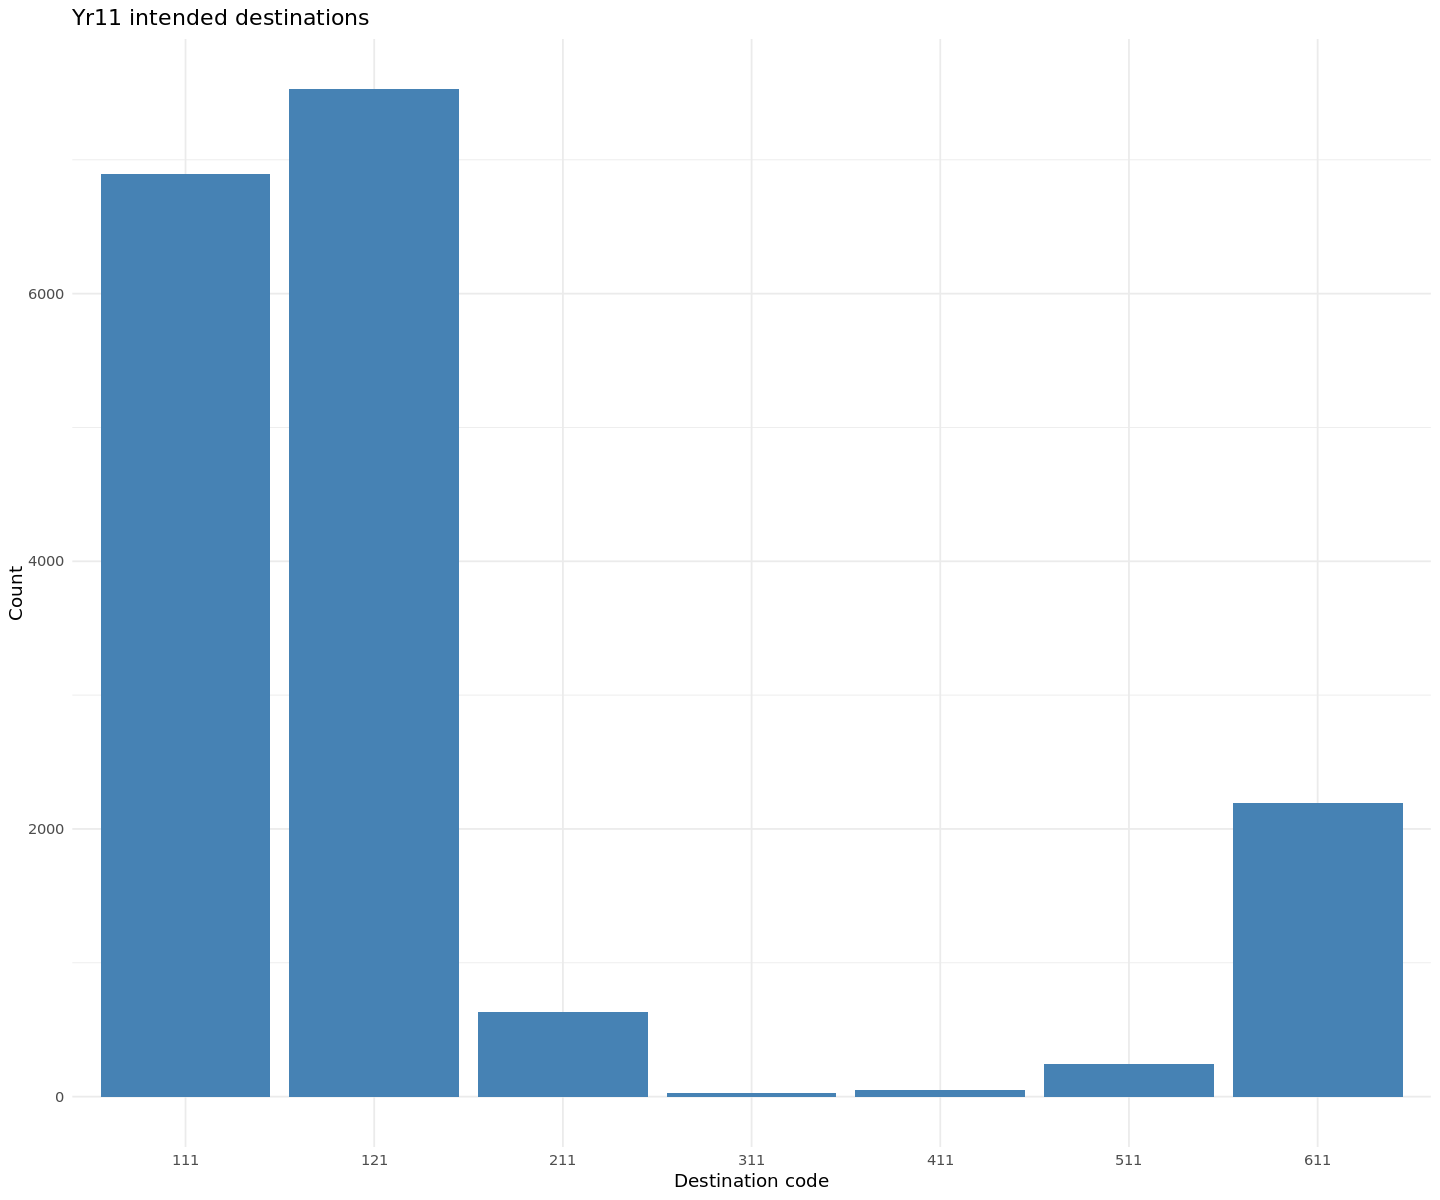

In [68]:
options(repr.plot.width = 12, repr.plot.height = 10)

ggplot(filter(destinations_filtered, !is.na(NCCIS_Year_11_Intended_Destination)), aes(x = NCCIS_Year_11_Intended_Destination)) +
      geom_bar(fill = "steelblue") +
      labs(title = "Yr11 intended destinations", x = "Destination code", y = "Count") +
      theme_minimal()

In [69]:
NEET_dest <- destinations_filtered |>
    filter(NCCIS_Year_11_Intended_Destination %in% c('411','511','611'))

In [70]:
NEET_dest |>
 group_by(cohort) |>
 tally()

cohort,n
<chr>,<int>
2000/01,1130
2001/02,1352


In [71]:
NEET_dest |> 
  group_by(cohort) |>
  summarise(num_unique = n_distinct(person_id))

cohort,num_unique
<chr>,<int>
2000/01,125
2001/02,134


In [72]:
NEET_dest |> 
  filter(person_id == '5C2105DDD9AB87620BB209C1D3EB10D0B62025614D92DA07BA4F229BC254D273')

person_id,NCCIS_ACADYR,NCCIS_MonthNo,NCCIS_Year_11_Intended_Destination,NCCIS_Current_Activity_Code,NCCIS_Current_Activity_Start_Date,NCCIS_NEET_Start_Date,NCCIS_Lead_LEA_Code,cohort
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
5C2105DDD9AB87620BB209C1D3EB10D0B62025614D92DA07BA4F229BC254D273,2018/2019,12,511,210,2018-09-05,NA,815,2001/02
5C2105DDD9AB87620BB209C1D3EB10D0B62025614D92DA07BA4F229BC254D273,2018/2019,8,511,210,2018-09-05,NA,815,2001/02
5C2105DDD9AB87620BB209C1D3EB10D0B62025614D92DA07BA4F229BC254D273,2018/2019,2,511,210,2018-09-05,NA,815,2001/02
5C2105DDD9AB87620BB209C1D3EB10D0B62025614D92DA07BA4F229BC254D273,2018/2019,6,511,210,2018-09-05,NA,815,2001/02
5C2105DDD9AB87620BB209C1D3EB10D0B62025614D92DA07BA4F229BC254D273,2018/2019,10,511,810,2018-09-01,NA,815,2001/02
5C2105DDD9AB87620BB209C1D3EB10D0B62025614D92DA07BA4F229BC254D273,2018/2019,11,511,210,2018-09-05,NA,815,2001/02
5C2105DDD9AB87620BB209C1D3EB10D0B62025614D92DA07BA4F229BC254D273,2018/2019,5,511,210,2018-09-05,NA,815,2001/02
5C2105DDD9AB87620BB209C1D3EB10D0B62025614D92DA07BA4F229BC254D273,2018/2019,9,511,810,2018-09-01,NA,815,2001/02
5C2105DDD9AB87620BB209C1D3EB10D0B62025614D92DA07BA4F229BC254D273,2018/2019,4,511,210,2018-09-05,NA,815,2001/02


In [73]:
NEET_dest |> 
  filter(person_id == '26EC80FD819A62ED03E3A9B47BB5F3F72807675A7B8079A1A392629CBD033260')

person_id,NCCIS_ACADYR,NCCIS_MonthNo,NCCIS_Year_11_Intended_Destination,NCCIS_Current_Activity_Code,NCCIS_Current_Activity_Start_Date,NCCIS_NEET_Start_Date,NCCIS_Lead_LEA_Code,cohort
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
26EC80FD819A62ED03E3A9B47BB5F3F72807675A7B8079A1A392629CBD033260,2018/2019,2,411,320,2018-09-05,NA,811,2001/02
26EC80FD819A62ED03E3A9B47BB5F3F72807675A7B8079A1A392629CBD033260,2018/2019,9,411,320,2018-09-05,NA,811,2001/02
26EC80FD819A62ED03E3A9B47BB5F3F72807675A7B8079A1A392629CBD033260,2018/2019,12,411,320,2018-09-05,NA,811,2001/02
26EC80FD819A62ED03E3A9B47BB5F3F72807675A7B8079A1A392629CBD033260,2018/2019,10,411,320,2018-09-05,NA,811,2001/02
26EC80FD819A62ED03E3A9B47BB5F3F72807675A7B8079A1A392629CBD033260,2018/2019,4,411,320,2018-09-05,NA,811,2001/02
26EC80FD819A62ED03E3A9B47BB5F3F72807675A7B8079A1A392629CBD033260,2018/2019,5,411,320,2018-09-05,NA,811,2001/02
26EC80FD819A62ED03E3A9B47BB5F3F72807675A7B8079A1A392629CBD033260,2018/2019,8,411,320,2018-09-05,NA,811,2001/02
26EC80FD819A62ED03E3A9B47BB5F3F72807675A7B8079A1A392629CBD033260,2018/2019,11,411,320,2018-09-05,NA,811,2001/02
26EC80FD819A62ED03E3A9B47BB5F3F72807675A7B8079A1A392629CBD033260,2018/2019,1,411,320,2018-09-05,NA,811,2001/02


In [74]:
NEET_dest |> 
  filter(NCCIS_Year_11_Intended_Destination == '611')

person_id,NCCIS_ACADYR,NCCIS_MonthNo,NCCIS_Year_11_Intended_Destination,NCCIS_Current_Activity_Code,NCCIS_Current_Activity_Start_Date,NCCIS_NEET_Start_Date,NCCIS_Lead_LEA_Code,cohort
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
A99B5F4C5D1A34FCA24B8C63A1F4CD08D479A13C6A3A443C0A78DC96F45B90D5,2017/2018,2,611,330,2017-08-21,NA,878,2000/01
59D31DC292BEDB99D598A00CE71257F4733F65F1C13596FA06B1989DC5F4E413,2017/2018,9,611,619,2017-09-01,2017-09-01,874,2000/01
494096F9B10CB17E72C3C9EB0696CFE8871F82A6FB59F6833A794E52575DDCF7,2018/2019,4,611,619,2018-09-01,2018-09-01,925,2001/02
83D83391B672E60C65E04FD43BAB01BA4D09EF35CC4A241A0463386F93149577,2018/2019,7,611,230,2018-09-03,NA,801,2001/02
E4ED8FB27BC71E66878E74329267C3C2F0939A0A9C1EC7BFD98628DA395BAADF,2018/2019,10,611,230,2018-09-01,NA,925,2001/02
082D44F8712320F25C3C2EA194BF8E20343D6551A45D05E14A457CE81870D1B1,2018/2019,11,611,220,2018-09-04,NA,812,2001/02
DBC7D6FBB4AF37D464372DA31B732C2FAC7407ED81E18D8146A77306F05AD756,2018/2019,1,611,210,2018-09-05,NA,815,2001/02
0A7B9B6B2AAE5FA68EF0C0F1C98B4C61B6F9A98775E044B0B77C977498EB046C,2018/2019,8,611,230,2018-09-05,NA,815,2001/02
06490B3EC6B7808C3962B2944C36EA3F223D1229B9B35465B49E55DB0B5B011A,2017/2018,1,611,270,2017-09-04,NA,815,2000/01


## Explore NEET activity

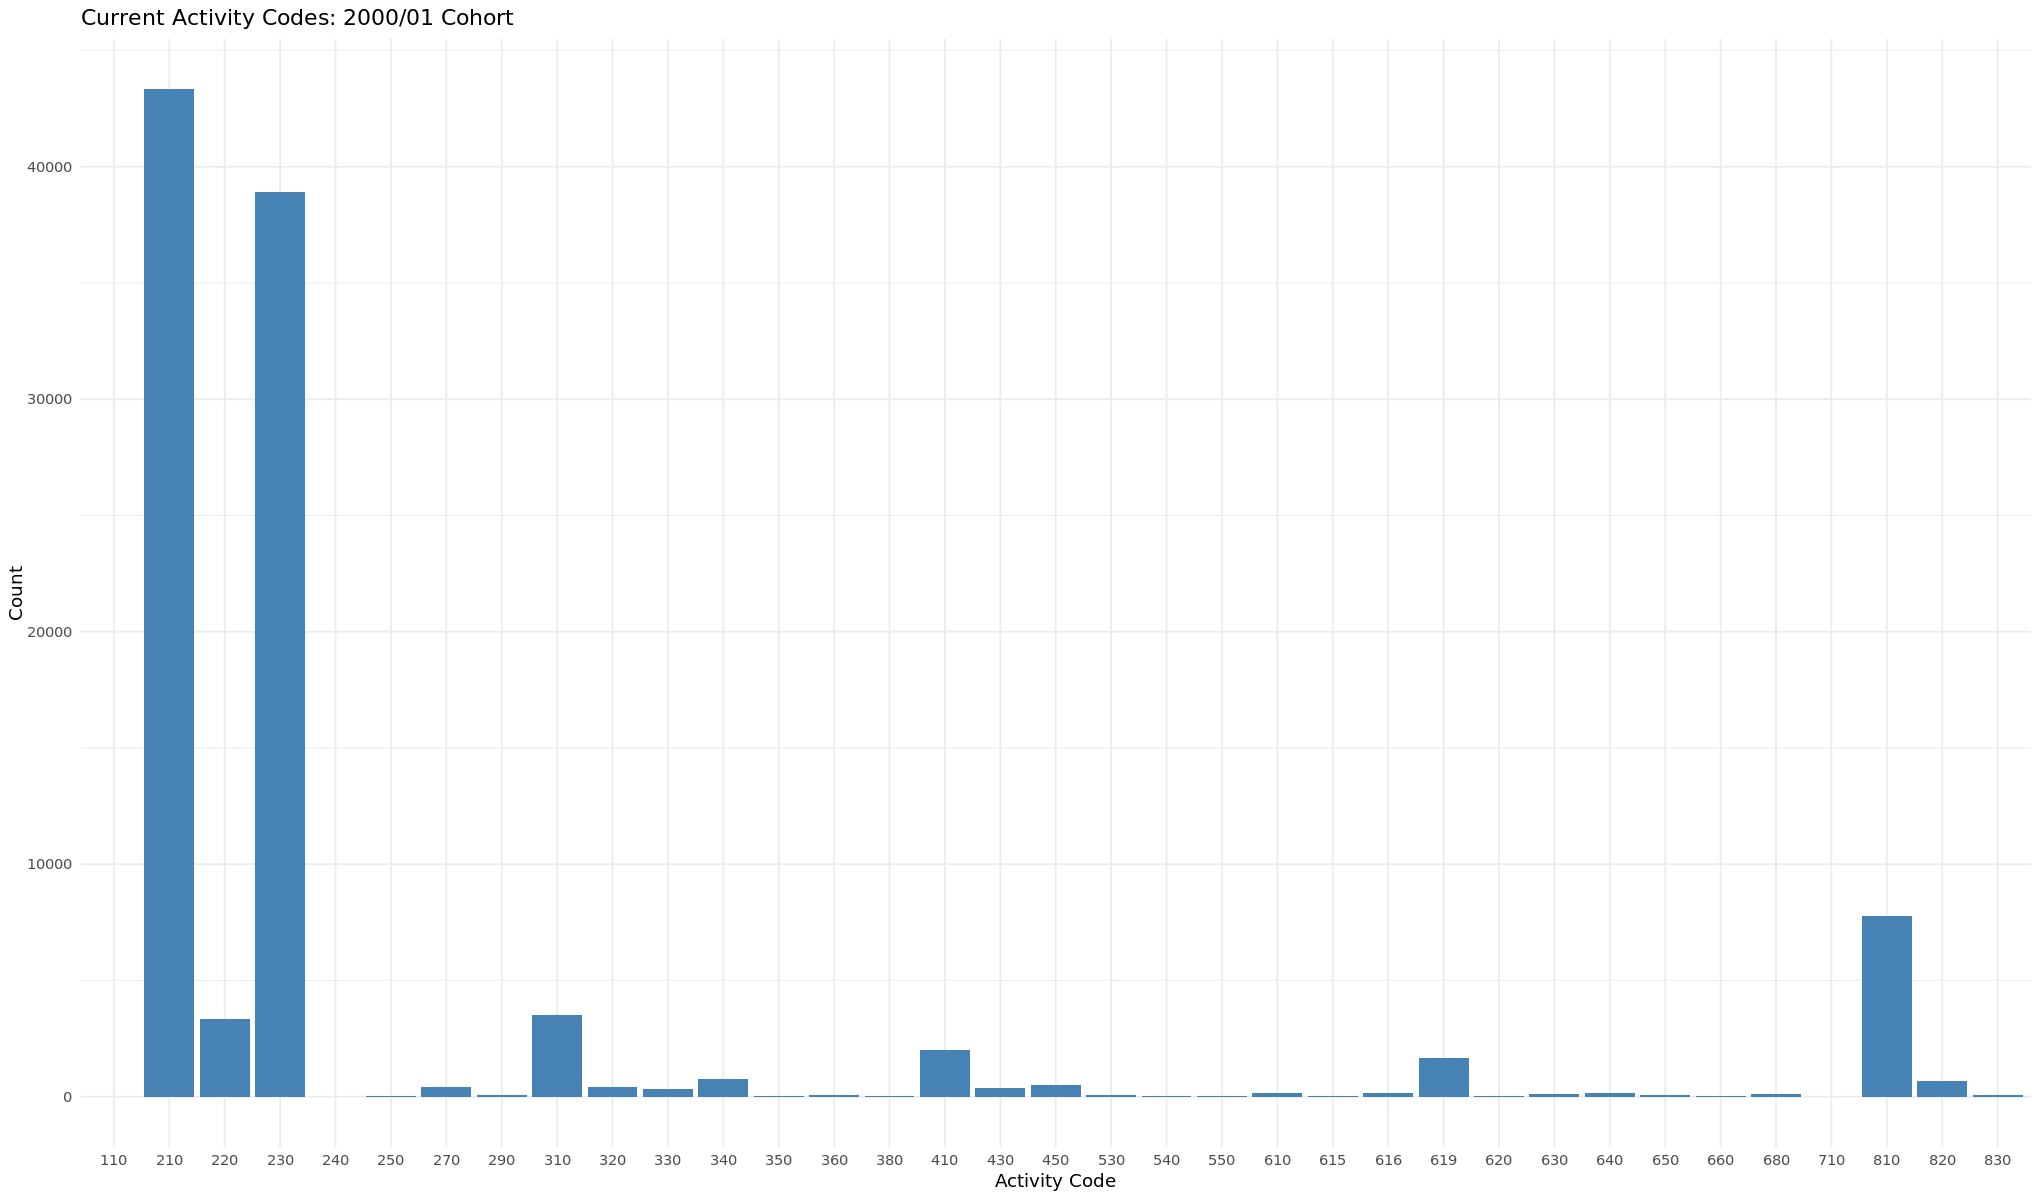

In [75]:
options(repr.plot.width = 17, repr.plot.height = 10)

destinations_filtered %>%
  filter(cohort == '2000/01') %>%
  ggplot(aes(x = NCCIS_Current_Activity_Code)) +
  geom_bar(fill = "steelblue") +
  labs(title = "Current Activity Codes: 2000/01 Cohort", x = "Activity Code", y = "Count") +
  theme_minimal()

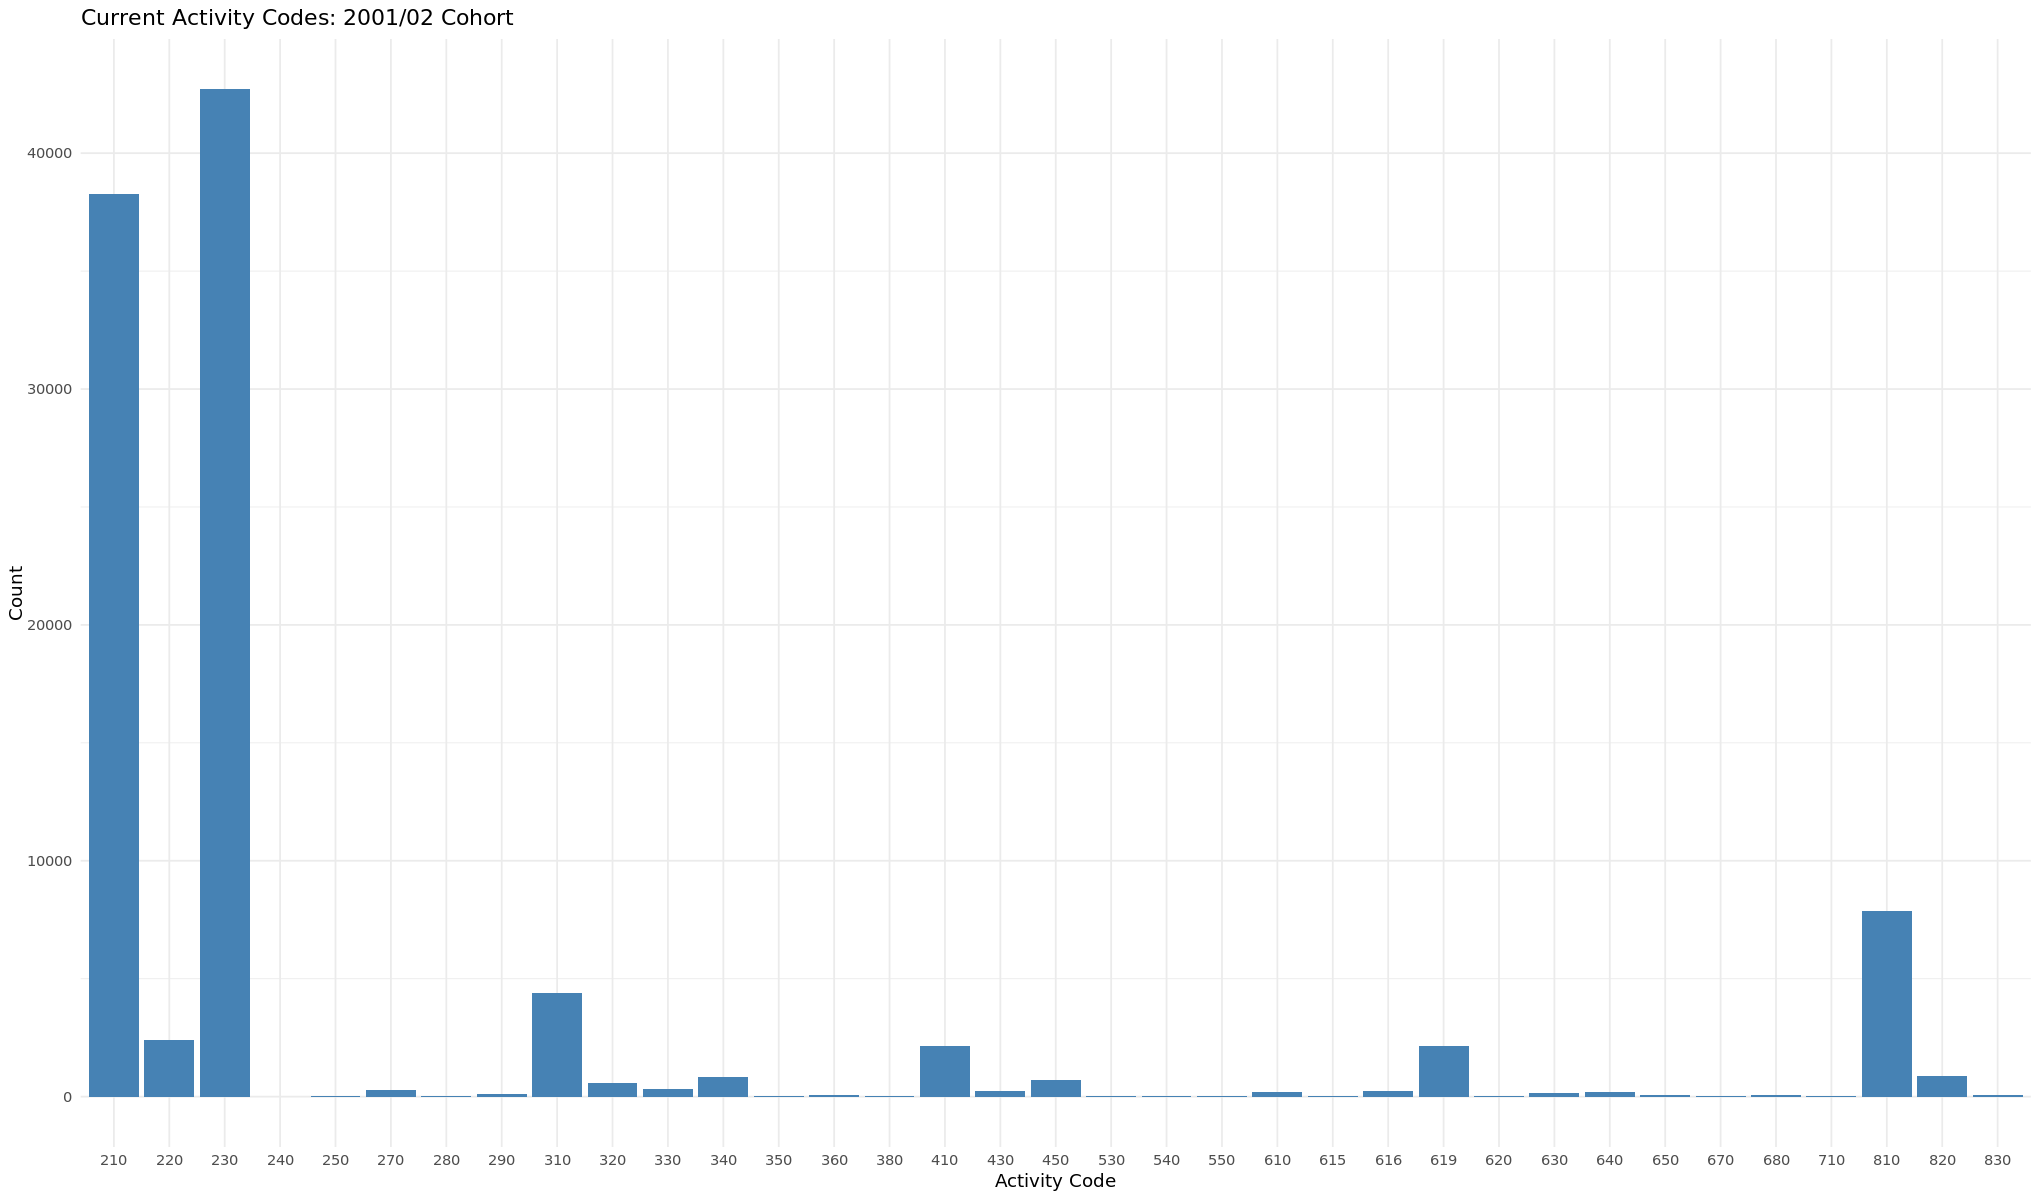

In [76]:
options(repr.plot.width = 17, repr.plot.height = 10)

destinations_filtered %>%
  filter(cohort == '2001/02') %>%
  ggplot(aes(x = NCCIS_Current_Activity_Code)) +
  geom_bar(fill = "steelblue") +
  labs(title = "Current Activity Codes: 2001/02 Cohort", x = "Activity Code", y = "Count") +
  theme_minimal()

In [77]:
NEET_activity <- destinations_filtered |>
    filter(NCCIS_Current_Activity_Code %in% c('540','610','615','616','619','620','630','640','650','660','670','680','710','810','820','830'))

# ,'710','810','820','830'

In [78]:
NEET_activity  |>
 group_by(cohort) |>
 tally()

cohort,n
<chr>,<int>
2000/01,10959
2001/02,11909


In [79]:
NEET_activity |> 
  group_by(cohort) |>
  summarise(num_unique = n_distinct(person_id))

cohort,num_unique
<chr>,<int>
2000/01,5395
2001/02,5275


In [80]:
NEET_activity |> 
  filter(person_id == '40C31E0E3726704907E720948AF22D6565BE912A5DCFAE5A4D54C123A423BD5A')

person_id,NCCIS_ACADYR,NCCIS_MonthNo,NCCIS_Year_11_Intended_Destination,NCCIS_Current_Activity_Code,NCCIS_Current_Activity_Start_Date,NCCIS_NEET_Start_Date,NCCIS_Lead_LEA_Code,cohort
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
40C31E0E3726704907E720948AF22D6565BE912A5DCFAE5A4D54C123A423BD5A,2018/2019,4,NA,619,2019-02-25,2019-02-25,380,2001/02
40C31E0E3726704907E720948AF22D6565BE912A5DCFAE5A4D54C123A423BD5A,2018/2019,8,NA,619,2019-02-25,2019-02-25,380,2001/02
40C31E0E3726704907E720948AF22D6565BE912A5DCFAE5A4D54C123A423BD5A,2018/2019,3,NA,619,2019-02-25,2019-02-25,380,2001/02
40C31E0E3726704907E720948AF22D6565BE912A5DCFAE5A4D54C123A423BD5A,2018/2019,6,NA,619,2019-02-25,2019-02-25,380,2001/02
40C31E0E3726704907E720948AF22D6565BE912A5DCFAE5A4D54C123A423BD5A,2018/2019,5,NA,619,2019-02-25,2019-02-25,380,2001/02
40C31E0E3726704907E720948AF22D6565BE912A5DCFAE5A4D54C123A423BD5A,2018/2019,7,NA,619,2019-02-25,2019-02-25,380,2001/02


In [81]:
NEET_activity_1718 <- NEET_activity |>
    filter(NCCIS_ACADYR == '2017/2018')

In [82]:
NEET_activity_1718 |> 
    group_by(NCCIS_Current_Activity_Code) |>
    summarise(num_unique = n_distinct(person_id))

NCCIS_Current_Activity_Code,num_unique
<chr>,<int>
540,2
610,45
615,9
616,97
619,524
620,3
630,22
640,27
650,17


In [83]:
NEET_activity_1718 |> 
  group_by(NCCIS_Current_Activity_Code) |>
    tally()

NCCIS_Current_Activity_Code,n
<chr>,<int>
540,7
610,148
615,11
616,160
619,1654
620,13
630,125
640,166
650,69


In [84]:
NEET_activity_1819 <- NEET_activity |>
    filter(NCCIS_ACADYR == '2018/2019')

In [85]:
NEET_activity_1819 |> 
    group_by(NCCIS_Current_Activity_Code) |>
    summarise(num_unique = n_distinct(person_id))

NCCIS_Current_Activity_Code,num_unique
<chr>,<int>
540,2
610,62
615,4
616,119
619,680
620,6
630,27
640,35
650,16


In [86]:
NEET_activity_1819 |> 
  group_by(NCCIS_Current_Activity_Code) |>
    tally()

NCCIS_Current_Activity_Code,n
<chr>,<int>
540,13
610,184
615,7
616,252
619,2136
620,28
630,148
640,184
650,71


In [87]:
NEET_activity |> 
  filter(person_id == '6B720C4F05F1A0DB90A73A75ADE360AB26D11EA77ACBA3657F98CC3769F427AC')

person_id,NCCIS_ACADYR,NCCIS_MonthNo,NCCIS_Year_11_Intended_Destination,NCCIS_Current_Activity_Code,NCCIS_Current_Activity_Start_Date,NCCIS_NEET_Start_Date,NCCIS_Lead_LEA_Code,cohort
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
6B720C4F05F1A0DB90A73A75ADE360AB26D11EA77ACBA3657F98CC3769F427AC,2018/2019,6,NA,830,2019-06-28,NA,380,2001/02
6B720C4F05F1A0DB90A73A75ADE360AB26D11EA77ACBA3657F98CC3769F427AC,2018/2019,8,NA,830,2019-06-28,NA,380,2001/02
6B720C4F05F1A0DB90A73A75ADE360AB26D11EA77ACBA3657F98CC3769F427AC,2018/2019,2,NA,619,2019-02-26,2018-12-06,380,2001/02
6B720C4F05F1A0DB90A73A75ADE360AB26D11EA77ACBA3657F98CC3769F427AC,2018/2019,12,NA,640,2018-12-06,2018-12-06,380,2001/02
6B720C4F05F1A0DB90A73A75ADE360AB26D11EA77ACBA3657F98CC3769F427AC,2018/2019,7,NA,830,2019-06-28,NA,380,2001/02
6B720C4F05F1A0DB90A73A75ADE360AB26D11EA77ACBA3657F98CC3769F427AC,2018/2019,3,NA,619,2019-02-26,2018-12-06,380,2001/02
6B720C4F05F1A0DB90A73A75ADE360AB26D11EA77ACBA3657F98CC3769F427AC,2018/2019,9,NA,810,2018-08-14,NA,380,2001/02
6B720C4F05F1A0DB90A73A75ADE360AB26D11EA77ACBA3657F98CC3769F427AC,2018/2019,4,NA,619,2019-02-26,2018-12-06,380,2001/02
6B720C4F05F1A0DB90A73A75ADE360AB26D11EA77ACBA3657F98CC3769F427AC,2018/2019,10,NA,810,2018-08-14,NA,380,2001/02


In [88]:
NEET_activity |> 
  filter(NCCIS_Current_Activity_Code == 830)

person_id,NCCIS_ACADYR,NCCIS_MonthNo,NCCIS_Year_11_Intended_Destination,NCCIS_Current_Activity_Code,NCCIS_Current_Activity_Start_Date,NCCIS_NEET_Start_Date,NCCIS_Lead_LEA_Code,cohort
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
BBC138EF2E1648D6FE2DC033157F1A931F4241CEDF3AE20AD788C5D0BA2063DD,2018/2019,3,NA,830,2019-03-28,NA,380,2001/02
6A484E7E45ECA7A7722DB9289200E93EA4445A6FD11E219F5C2FE0222184F0B2,2017/2018,7,NA,830,2018-01-30,NA,380,2000/01
777D714DF89FD429075F60E0F8EDB810CC49467AD3891259D90F8AB68AB17365,2017/2018,1,NA,830,2018-01-29,NA,380,2000/01
FA9F2C8A1CD0DB3577DEC062D5CF7989684A288E27196F6C96DE787B4F922A8C,2018/2019,3,NA,830,2019-02-27,NA,380,2001/02
6B720C4F05F1A0DB90A73A75ADE360AB26D11EA77ACBA3657F98CC3769F427AC,2018/2019,6,NA,830,2019-06-28,NA,380,2001/02
F3F0A4C2D125E42E7D9B1FE9743420F78E9EB8045B0C70E5D475EA5A72C3A71C,2017/2018,12,NA,830,2017-08-15,NA,380,2000/01
BDB321813E70EF2CEFAD84FDE8CC710E98E192F585AFDC7F8D85CD9819579E0F,2018/2019,4,NA,830,2019-03-11,NA,380,2001/02
6740A6FB3BCDEFA29131F12EF3B56528BA10E66CB5BE80164203B62F52778E55,2018/2019,6,NA,830,2018-10-22,NA,380,2001/02
EE7845EC75B224F12468CE881715440AC1910374E35002803A04E7FBEA4274D8,2018/2019,5,NA,830,2018-10-31,NA,381,2001/02


## Tidy destinations and activity

In [89]:
destinations_clean <- destinations_filtered |>
    mutate(Intended_destination = 
        case_when(
            NCCIS_Year_11_Intended_Destination %in% c('111','121','211','311') ~ 'EET',
            NCCIS_Year_11_Intended_Destination %in% c('411','511') ~ 'NEET',
            TRUE ~ NA
            )
        )

In [90]:
destinations_clean |>
    group_by(Intended_destination) |>
    tally()

Intended_destination,n
<chr>,<int>
EET,15078
NEET,290
NA,194906


In [91]:
destinations_clean <- destinations_clean |>
    mutate(Current_activity = 
           case_when(
               NCCIS_Current_Activity_Code %in% c('210','220','230','240','250','260','270','280','290') ~ 'Education',
               NCCIS_Current_Activity_Code %in% c('310','320','330','340','350','360','380','381','550') ~ 'Employment',
               NCCIS_Current_Activity_Code %in% c('410','430','440','450','460') ~ 'Training',
               NCCIS_Current_Activity_Code %in% c('530','540','610','615','616','619','620','630','640','650','660','670','680','710') ~ 'NEET',
               NCCIS_Current_Activity_Code %in% c('810','820') ~ NA,
               NCCIS_Current_Activity_Code == '830' ~ 'Refused',
               TRUE ~ NA
               )
           )
               

In [92]:
destinations_clean |>
    group_by(Current_activity) |>
    tally()

Current_activity,n
<chr>,<int>
Education,169951
Employment,11412
NEET,5678
Refused,138
Training,5931
NA,17164


In [93]:
destinations_clean <- destinations_clean |>
    mutate(NEET_detail = 
           case_when(
               NCCIS_Current_Activity_Code == '530' ~ 'Re-engagement',
               NCCIS_Current_Activity_Code == '540' ~ 'Working: no reward',
               NCCIS_Current_Activity_Code == '610' ~ 'Not ready',
               NCCIS_Current_Activity_Code == '615' ~ 'Start date agreed',
               NCCIS_Current_Activity_Code == '616' ~ 'Start date agreed',
               NCCIS_Current_Activity_Code == '619' ~ 'Seeking EET',
               NCCIS_Current_Activity_Code == '620' ~ 'Carer',
               NCCIS_Current_Activity_Code == '630' ~ 'Teen parent',
               NCCIS_Current_Activity_Code == '640' ~ 'Illness',
               NCCIS_Current_Activity_Code == '650' ~ 'Pregnancy',
               NCCIS_Current_Activity_Code == '660' ~ 'Religious grounds',
               NCCIS_Current_Activity_Code == '670' ~ 'Economically inactive',
               NCCIS_Current_Activity_Code == '680' ~ 'Other',
               NCCIS_Current_Activity_Code == '710' ~ 'Custody',
               TRUE ~ NA
               )
           )

In [94]:
destinations_clean |>
    group_by(NEET_detail) |>
    tally()

NEET_detail,n
<chr>,<int>
Carer,41
Custody,9
Economically inactive,5
Illness,350
Not ready,332
Other,172
Pregnancy,140
Re-engagement,110
Religious grounds,6


In [95]:
head(destinations_clean)

person_id,NCCIS_ACADYR,NCCIS_MonthNo,NCCIS_Year_11_Intended_Destination,NCCIS_Current_Activity_Code,NCCIS_Current_Activity_Start_Date,NCCIS_NEET_Start_Date,NCCIS_Lead_LEA_Code,cohort,Intended_destination,Current_activity,NEET_detail
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
78A31FE77B8702EC379E452B50B3D3C195ECE9EC5E11E564D61F2C58BC1097B2,2017/2018,7,NA,810,2017-08-17,NA,394,2000/01,NA,NA,NA
A99B5F4C5D1A34FCA24B8C63A1F4CD08D479A13C6A3A443C0A78DC96F45B90D5,2017/2018,2,611,330,2017-08-21,NA,878,2000/01,NA,Employment,NA
BAE7885256B1D1D955EBD8C2C1472E978555AECCEF037E08906B654AD7932243,2017/2018,9,NA,810,2017-09-01,NA,382,2000/01,NA,NA,NA
B71B50E7395A4BF2F32487DA92CBCC5DD33BDBEDADBCEDC165B55A9BCD1D5D78,2017/2018,11,NA,810,2017-09-01,NA,335,2000/01,NA,NA,NA
5E739404B582EDF43D0F51B41137C5B682D29E1167C584D505C260534728E1F0,2017/2018,9,NA,810,2017-09-01,NA,333,2000/01,NA,NA,NA
CC74158D75C1FBDB0EE538D37FFA1075C6E2B5D1ED5E0D121BC450437521F34B,2017/2018,9,NA,810,2017-09-01,NA,382,2000/01,NA,NA,NA


In [96]:
destinations_clean <- destinations_clean |>
    select(-c(NCCIS_Year_11_Intended_Destination, NCCIS_Current_Activity_Code, NCCIS_Current_Activity_Start_Date, NCCIS_NEET_Start_Date, NCCIS_Lead_LEA_Code, cohort))

In [97]:
head(destinations_clean)

person_id,NCCIS_ACADYR,NCCIS_MonthNo,Intended_destination,Current_activity,NEET_detail
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>
78A31FE77B8702EC379E452B50B3D3C195ECE9EC5E11E564D61F2C58BC1097B2,2017/2018,7,NA,NA,NA
A99B5F4C5D1A34FCA24B8C63A1F4CD08D479A13C6A3A443C0A78DC96F45B90D5,2017/2018,2,NA,Employment,NA
BAE7885256B1D1D955EBD8C2C1472E978555AECCEF037E08906B654AD7932243,2017/2018,9,NA,NA,NA
B71B50E7395A4BF2F32487DA92CBCC5DD33BDBEDADBCEDC165B55A9BCD1D5D78,2017/2018,11,NA,NA,NA
5E739404B582EDF43D0F51B41137C5B682D29E1167C584D505C260534728E1F0,2017/2018,9,NA,NA,NA
CC74158D75C1FBDB0EE538D37FFA1075C6E2B5D1ED5E0D121BC450437521F34B,2017/2018,9,NA,NA,NA


## Destinations single record

In [98]:
destinations_clean |>
  group_by(person_id, NCCIS_MonthNo) |> 
  filter(n() > 1) |> 
  summarise(count = n(), .groups = "drop") |> 
  summarise(num_persons_with_duplicates = n_distinct(person_id))

num_persons_with_duplicates
<int>
450


In [99]:
destinations_clean <- destinations_clean |>
  arrange(person_id, NCCIS_MonthNo, Current_activity)

In [100]:
destinations_clean |>
  group_by(person_id, NCCIS_MonthNo) |> 
  filter(n() > 1)

person_id,NCCIS_ACADYR,NCCIS_MonthNo,Intended_destination,Current_activity,NEET_detail
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>
00A6CFE5C25E69EC51F67C74E4F40F8AECFE43014AD77CBCB2ADA9ECBBB96BA6,2018/2019,10,EET,Education,NA
00A6CFE5C25E69EC51F67C74E4F40F8AECFE43014AD77CBCB2ADA9ECBBB96BA6,2018/2019,10,NA,NA,NA
00A6CFE5C25E69EC51F67C74E4F40F8AECFE43014AD77CBCB2ADA9ECBBB96BA6,2018/2019,11,EET,Education,NA
00A6CFE5C25E69EC51F67C74E4F40F8AECFE43014AD77CBCB2ADA9ECBBB96BA6,2018/2019,11,NA,NA,NA
00A6CFE5C25E69EC51F67C74E4F40F8AECFE43014AD77CBCB2ADA9ECBBB96BA6,2018/2019,12,NA,Education,NA
00A6CFE5C25E69EC51F67C74E4F40F8AECFE43014AD77CBCB2ADA9ECBBB96BA6,2018/2019,12,NA,NA,NA
017282C1ED168B171D541E45651FBAB05FF29EDE770EAAB54F845CADCC27B33B,2017/2018,1,NA,Education,NA
017282C1ED168B171D541E45651FBAB05FF29EDE770EAAB54F845CADCC27B33B,2017/2018,1,EET,Education,NA
017282C1ED168B171D541E45651FBAB05FF29EDE770EAAB54F845CADCC27B33B,2017/2018,2,NA,Education,NA


#### split intended destinations and currect activity before removing 'not known' duplicates

In [101]:
dest_split <- destinations_clean |>
    select(-c(Current_activity, NEET_detail))

In [102]:
dest_split <- dest_split |>
  arrange(person_id, Intended_destination)

In [103]:
dest_split |>
  group_by(person_id) |> 
  filter(n() > 1)

person_id,NCCIS_ACADYR,NCCIS_MonthNo,Intended_destination
<chr>,<chr>,<dbl>,<chr>
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,1,NA
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,2,NA
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,3,NA
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,4,NA
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,5,NA
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,6,NA
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,7,NA
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,8,NA
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,9,NA


In [104]:
# order of priority: EET, NEET, NA
dest_split_clean <- dest_split |>
    group_by(person_id) |> 
    distinct(person_id, .keep_all = TRUE) |>
    select(c(person_id,Intended_destination))

In [105]:
dest_split_clean |>
    group_by(person_id) |> 
      filter(n() > 1) |> 
      summarise(count = n(), .groups = "drop") |> 
      summarise(num_persons_with_duplicates = n_distinct(person_id))

num_persons_with_duplicates
<int>
0


In [106]:
head(dest_split_clean)

person_id,Intended_destination
<chr>,<chr>
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,NA
00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,NA
0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,NA
0013020C6ED2FF78BCA8E5F2D0B9B16E66C50B6A2AABB754FB63314CFE3A2EC7,NA
00149D26484ED3BE2DEF154B8DB53A36B1A9FF0839C447A2CE19B0750225BA66,NA
0014DF7EADF7C22A0FD2F6862B6F06778B199F1F2D61242125DA8EC539E6275D,NA


In [107]:
activ_split <- destinations_clean |>
    select(-Intended_destination)

In [108]:
# automatic order of priority: Edu, Emp, NEET, Refused, Train, NA
activ_split <- activ_split |>
    mutate(Current_activity = factor(Current_activity, levels = c("Education", "Employment", "Training", "NEET", "Refused", NA ))) |>
    arrange(person_id, NCCIS_MonthNo, Current_activity)

In [109]:
activ_split |>
  group_by(person_id, NCCIS_ACADYR, NCCIS_MonthNo) |> 
  filter(n() > 1)

person_id,NCCIS_ACADYR,NCCIS_MonthNo,Current_activity,NEET_detail
<chr>,<chr>,<dbl>,<fct>,<chr>
00A6CFE5C25E69EC51F67C74E4F40F8AECFE43014AD77CBCB2ADA9ECBBB96BA6,2018/2019,10,Education,NA
00A6CFE5C25E69EC51F67C74E4F40F8AECFE43014AD77CBCB2ADA9ECBBB96BA6,2018/2019,10,NA,NA
00A6CFE5C25E69EC51F67C74E4F40F8AECFE43014AD77CBCB2ADA9ECBBB96BA6,2018/2019,11,Education,NA
00A6CFE5C25E69EC51F67C74E4F40F8AECFE43014AD77CBCB2ADA9ECBBB96BA6,2018/2019,11,NA,NA
00A6CFE5C25E69EC51F67C74E4F40F8AECFE43014AD77CBCB2ADA9ECBBB96BA6,2018/2019,12,Education,NA
00A6CFE5C25E69EC51F67C74E4F40F8AECFE43014AD77CBCB2ADA9ECBBB96BA6,2018/2019,12,NA,NA
017282C1ED168B171D541E45651FBAB05FF29EDE770EAAB54F845CADCC27B33B,2017/2018,1,Education,NA
017282C1ED168B171D541E45651FBAB05FF29EDE770EAAB54F845CADCC27B33B,2017/2018,1,Education,NA
017282C1ED168B171D541E45651FBAB05FF29EDE770EAAB54F845CADCC27B33B,2017/2018,2,Education,NA


In [110]:
activ_split |>
    filter(person_id == '0BA571FAB8736DC2F5593C7CF04A1E755E046E4A8872FB4FD224C7049107C7BE')

person_id,NCCIS_ACADYR,NCCIS_MonthNo,Current_activity,NEET_detail
<chr>,<chr>,<dbl>,<fct>,<chr>
0BA571FAB8736DC2F5593C7CF04A1E755E046E4A8872FB4FD224C7049107C7BE,2017/2018,1,NEET,Seeking EET
0BA571FAB8736DC2F5593C7CF04A1E755E046E4A8872FB4FD224C7049107C7BE,2017/2018,2,NEET,Seeking EET
0BA571FAB8736DC2F5593C7CF04A1E755E046E4A8872FB4FD224C7049107C7BE,2017/2018,3,NEET,Seeking EET
0BA571FAB8736DC2F5593C7CF04A1E755E046E4A8872FB4FD224C7049107C7BE,2017/2018,4,NEET,Seeking EET
0BA571FAB8736DC2F5593C7CF04A1E755E046E4A8872FB4FD224C7049107C7BE,2017/2018,5,NEET,Seeking EET
0BA571FAB8736DC2F5593C7CF04A1E755E046E4A8872FB4FD224C7049107C7BE,2017/2018,6,Refused,NA
0BA571FAB8736DC2F5593C7CF04A1E755E046E4A8872FB4FD224C7049107C7BE,2017/2018,7,Refused,NA
0BA571FAB8736DC2F5593C7CF04A1E755E046E4A8872FB4FD224C7049107C7BE,2017/2018,8,Refused,NA
0BA571FAB8736DC2F5593C7CF04A1E755E046E4A8872FB4FD224C7049107C7BE,2017/2018,9,NEET,Seeking EET


In [111]:
# manual order of priority
activ_split_clean <- activ_split |>
    group_by(person_id, NCCIS_ACADYR, NCCIS_MonthNo) |> 
    distinct(person_id, NCCIS_MonthNo, .keep_all = TRUE)

In [112]:
activ_split_clean |>
    group_by(person_id, NCCIS_ACADYR, NCCIS_MonthNo) |> 
      filter(n() > 1) |> 
      summarise(count = n(), .groups = "drop") |> 
      summarise(num_persons_with_duplicates = n_distinct(person_id))

num_persons_with_duplicates
<int>
0


In [113]:
activ_split_clean

person_id,NCCIS_ACADYR,NCCIS_MonthNo,Current_activity,NEET_detail
<chr>,<chr>,<dbl>,<fct>,<chr>
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,1,Education,NA
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,2,Education,NA
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,3,Education,NA
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,4,Education,NA
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,5,Education,NA
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,6,Education,NA
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,7,Education,NA
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,8,Education,NA
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,9,Education,NA


#### Re-join and pivot wide

In [114]:
dest_joined <- activ_split_clean |>
    left_join(dest_split_clean, by = join_by(person_id)) |>
    select(c(person_id,NCCIS_ACADYR,Intended_destination,NCCIS_MonthNo,Current_activity,NEET_detail))

In [115]:
dest_joined |>
    group_by(person_id, NCCIS_ACADYR, NCCIS_MonthNo) |> 
      filter(n() > 1) |> 
      summarise(count = n(), .groups = "drop") |> 
      summarise(num_persons_with_duplicates = n_distinct(person_id))

num_persons_with_duplicates
<int>
0


In [116]:
dest_joined |>
    group_by(person_id, NCCIS_MonthNo) |> 
      filter(n() > 1)

person_id,NCCIS_ACADYR,Intended_destination,NCCIS_MonthNo,Current_activity,NEET_detail
<chr>,<chr>,<chr>,<dbl>,<fct>,<chr>


In [1]:
dest_joined 

ERROR: Error: object 'dest_joined' not found


In [118]:
dest_joined |>
    group_by(Current_activity) |>
    tally()

Current_activity,n
<fct>,<int>
Education,168593
Employment,11245
Training,5838
NEET,5498
Refused,138
NA,16124


In [119]:
dest_joined |>
    filter(person_id == '0BA571FAB8736DC2F5593C7CF04A1E755E046E4A8872FB4FD224C7049107C7BE')

person_id,NCCIS_ACADYR,Intended_destination,NCCIS_MonthNo,Current_activity,NEET_detail
<chr>,<chr>,<chr>,<dbl>,<fct>,<chr>
0BA571FAB8736DC2F5593C7CF04A1E755E046E4A8872FB4FD224C7049107C7BE,2017/2018,NA,1,NEET,Seeking EET
0BA571FAB8736DC2F5593C7CF04A1E755E046E4A8872FB4FD224C7049107C7BE,2017/2018,NA,2,NEET,Seeking EET
0BA571FAB8736DC2F5593C7CF04A1E755E046E4A8872FB4FD224C7049107C7BE,2017/2018,NA,3,NEET,Seeking EET
0BA571FAB8736DC2F5593C7CF04A1E755E046E4A8872FB4FD224C7049107C7BE,2017/2018,NA,4,NEET,Seeking EET
0BA571FAB8736DC2F5593C7CF04A1E755E046E4A8872FB4FD224C7049107C7BE,2017/2018,NA,5,NEET,Seeking EET
0BA571FAB8736DC2F5593C7CF04A1E755E046E4A8872FB4FD224C7049107C7BE,2017/2018,NA,6,Refused,NA
0BA571FAB8736DC2F5593C7CF04A1E755E046E4A8872FB4FD224C7049107C7BE,2017/2018,NA,7,Refused,NA
0BA571FAB8736DC2F5593C7CF04A1E755E046E4A8872FB4FD224C7049107C7BE,2017/2018,NA,8,Refused,NA
0BA571FAB8736DC2F5593C7CF04A1E755E046E4A8872FB4FD224C7049107C7BE,2017/2018,NA,9,NEET,Seeking EET


In [120]:
# Save as CSV

In [142]:
write.csv(destinations_wide, "data/destinations_wide.csv", row.names = FALSE)

In [139]:
destinations_wide <- dest_joined |>
    select(-(NEET_detail)) |>
    pivot_wider(
        names_from = NCCIS_MonthNo,
        values_from = Current_activity,
        values_fill = NA
        ) |>
    select(c(person_id,NCCIS_ACADYR,Intended_destination,'9','10','11','12','1','2','3','4','5','6','7','8'))

In [141]:
head(destinations_wide)

person_id,NCCIS_ACADYR,Intended_destination,9,10,11,12,1,2,3,4,5,6,7,8
<chr>,<chr>,<chr>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education
00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education
0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,2018/2019,NA,Education,Education,Education,Education,Education,Education,NEET,NEET,NEET,NEET,NEET,NEET
0013020C6ED2FF78BCA8E5F2D0B9B16E66C50B6A2AABB754FB63314CFE3A2EC7,2018/2019,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education
00149D26484ED3BE2DEF154B8DB53A36B1A9FF0839C447A2CE19B0750225BA66,2017/2018,NA,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,NA
0014DF7EADF7C22A0FD2F6862B6F06778B199F1F2D61242125DA8EC539E6275D,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education


In [120]:
# Save as CSV

In [142]:
write.csv(destinations_wide, "data/destinations_wide.csv", row.names = FALSE)

In [122]:
dest_joined_detail <- dest_joined |>
    mutate(Current_activity = case_when(
        Current_activity == "NEET" & !is.na(NEET_detail) ~ paste0("NEET: ", NEET_detail),
        TRUE ~ Current_activity
  ))

In [123]:
dest_joined_detail

person_id,NCCIS_ACADYR,Intended_destination,NCCIS_MonthNo,Current_activity,NEET_detail
<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,NA,1,Education,NA
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,NA,2,Education,NA
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,NA,3,Education,NA
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,NA,4,Education,NA
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,NA,5,Education,NA
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,NA,6,Education,NA
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,NA,7,Education,NA
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,NA,8,Education,NA
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,NA,9,Education,NA


In [139]:
destinations_wide_detail <- dest_joined |>
    select(-(NEET_detail)) |>
    pivot_wider(
        names_from = NCCIS_MonthNo,
        values_from = Current_activity,
        values_fill = NA
        ) |>
    select(c(person_id,NCCIS_ACADYR,Intended_destination,'9','10','11','12','1','2','3','4','5','6','7','8'))

In [125]:
destinations_wide_detail

person_id,NCCIS_ACADYR,Intended_destination,9,10,11,12,1,2,3,4,5,6,7,8
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education
00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education
0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,2018/2019,NA,Education,Education,Education,Education,Education,Education,NEET: Not ready,NEET: Not ready,NEET: Not ready,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET
0013020C6ED2FF78BCA8E5F2D0B9B16E66C50B6A2AABB754FB63314CFE3A2EC7,2018/2019,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education
00149D26484ED3BE2DEF154B8DB53A36B1A9FF0839C447A2CE19B0750225BA66,2017/2018,NA,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,NA
0014DF7EADF7C22A0FD2F6862B6F06778B199F1F2D61242125DA8EC539E6275D,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education
0018E26A40A6299391164D4918658B0B1248367C762DCE6D2FDF1AE131A9138C,2018/2019,NA,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,NA
0019031CD62586D59268772800516ED50CDF1EF7DE46488542BB031850F6E68A,2018/2019,NA,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education
001B7CEB7B4CC529920A0B9F5B83D1AC0019E5DC44B3FBB3CEF665C331C0C3B6,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,NA


In [126]:
destinations_wide_detail |>
    filter(Intended_destination == 'NEET')

person_id,NCCIS_ACADYR,Intended_destination,9,10,11,12,1,2,3,4,5,6,7,8
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
16DCD3CC01BA496BAA6A47103896B049CE296148BE93D78898113BCF5E8B8A96,2018/2019,NEET,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education
1F4273F12E1089F49E7CB1787781AFA6B3667E430DDB7ED2FFE89761387E9263,2018/2019,NEET,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education
253BAEDD9AA508A0AFDFF44D5E9A8D2FF9A6EC47488F89B3F2E07375B91FB7E9,2018/2019,NEET,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education
26EC80FD819A62ED03E3A9B47BB5F3F72807675A7B8079A1A392629CBD033260,2018/2019,NEET,Employment,Employment,Employment,Employment,Employment,Employment,Employment,Employment,Employment,Employment,Employment,Employment
2DFF8150F3BC4F77082D990B7E365E224AD497858F1D2F6E0EC49EAAA5E31335,2017/2018,NEET,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education
33494644E5D434D1FEF32CFA2D8AA129669BBE95DA353750211778B4698CE069,2018/2019,NEET,NA,NA,NA,Employment,Employment,Employment,Employment,Employment,Employment,Employment,Employment,Employment
3572B1886F732DEA0C9BCB3624B2A5843BC5C966817D181E51AB71139756C14F,2017/2018,NEET,NA,Education,NA,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET
37A670987345664AEDDEBC25A8AF1DD0A0D9A364490756FC859DAA2400C608C2,2018/2019,NEET,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education
38A1E5FCB1F7C0D24A0CE176CE1AA1CDB1DD4882BFEDE9AE13592D488F980EF0,2018/2019,NEET,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education


#### Classify records...

In [126]:
# N = 17543

#### save destinations with NEET detail as csv 

In [127]:
write.csv(destinations_wide_detail, "data/destinations_wide_detail.csv", row.names = FALSE)

In [129]:
destinations_wide_detail |>
    filter(if_all(`9`:`8`, ~ . == "Education")) |>
    nrow()

[1] 6080

In [130]:
destinations_wide_detail |>
    filter(if_all(`9`:`8`, ~ . == "Employment")) |>
    nrow()

[1] 290

In [131]:
destinations_wide_detail |>
    filter(if_all(`9`:`8`, ~ . == "Training")) |>
    nrow()

[1] 37

In [132]:
destinations_wide_detail |>
    filter(if_all(`9`:`8`, ~ . == "Refused")) |>
    nrow()

[1] 1

In [133]:
destinations_wide_detail |>
    filter(if_all(`9`:`8`, is.na)) |>
    nrow()

[1] 182

In [134]:
# records with ALL neet status
destinations_wide_detail |>
    filter(if_all(`9`:`8`, ~ str_starts(., "NEET"))) |>
    nrow()

[1] 29

In [135]:
# records with ANY neet status
destinations_wide_detail |>
    filter(if_any(`9`:`8`, ~ str_starts(., "NEET"))) |>
    nrow()

[1] 1390

In [136]:
destinations_wide_detail <- destinations_wide_detail |>
    rowwise() |>
    mutate(neet_count = sum(str_starts(c_across(`9`:`8`), "NEET"), na.rm = TRUE))

In [138]:
# records with majority neet status
destinations_wide_detail |>
    filter(neet_count >= 9) 

person_id,NCCIS_ACADYR,Intended_destination,9,10,11,12,1,2,3,4,5,6,7,8,neet_count
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
00D2D54BE54AA2D95A4868BF01E6147645BD35B1DE9161DC1AC32D1B2570E2E7,2017/2018,NA,NEET: Seeking EET,Employment,Employment,Employment,NEET: Seeking EET,NEET: Seeking EET,NEET: Pregnancy,NEET: Pregnancy,NEET: Pregnancy,NEET: Teen parent,NEET: Teen parent,NEET: Teen parent,9
02595CE994DD5ECD2F333CA5DBBD7B837CBF7D7DA266D568C3E685E6548AE7C4,2018/2019,NA,Education,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,11
03775A2E25D4145883BF71B42DA0A6E54F6ACECB0D883B47F5E145FC8645D83B,2017/2018,NA,NA,NA,NA,NEET: Not ready,NEET: Not ready,NEET: Not ready,NEET: Not ready,NEET: Not ready,NEET: Not ready,NEET: Not ready,NEET: Not ready,NEET: Not ready,9
0BA571FAB8736DC2F5593C7CF04A1E755E046E4A8872FB4FD224C7049107C7BE,2017/2018,NA,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,Refused,Refused,Refused,9
0C824E388720F4BE7B318BE44F24E5B388D46DB77AB71198426BA62C12092F7A,2017/2018,NA,NEET: Not ready,NEET: Not ready,NEET: Not ready,NEET: Not ready,NEET: Illness,NEET: Illness,NEET: Illness,NEET: Illness,NEET: Illness,NEET: Illness,NEET: Illness,NEET: Illness,12
0DC4FC68F13B38B8DBB02D6366CFC8F62D560F1672638BB3E9CFE93FAC516AC5,2018/2019,NA,NA,NA,NA,NEET: Illness,NEET: Illness,NEET: Illness,NEET: Illness,NEET: Illness,NEET: Illness,NEET: Illness,NEET: Illness,NEET: Illness,9
162B7DE34DC5E1E98CB7CE1C0987E20DDD3E5E9E1583AD0E440EC6B6D858AE1F,2017/2018,NA,NEET: Re-engagement,NEET: Re-engagement,NEET: Re-engagement,NEET: Re-engagement,NEET: Re-engagement,NEET: Re-engagement,NEET: Re-engagement,NEET: Re-engagement,NEET: Re-engagement,NEET: Re-engagement,NEET: Re-engagement,NEET: Re-engagement,12
16CCD5CDF042931FE711F9B2D9739455275BD8F40BBBAA5A2F06DAC3BB981D77,2017/2018,NA,NEET: Seeking EET,NEET: Not ready,NEET: Not ready,NEET: Seeking EET,NEET: Seeking EET,NEET: Not ready,Employment,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Not ready,NEET: Start date agreed,11
176CF1A5DFEA7AA131EBA908B307E884FBF560F87E2200C6D868623FD38CA3FF,2017/2018,NA,NA,NA,NEET: Other,NEET: Other,NEET: Other,NEET: Other,NEET: Other,NEET: Other,NEET: Other,NEET: Other,NEET: Other,NEET: Other,10
